In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

QUESTION 1

In [157]:
# Data for the two stores and months
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
store_1_sales = [350, 460, 20, 160, 580, 250, 210, 100, 200, 510, 290, 380]
store_2_sales = [520, 180, 260, 380, 80, 500, 630, 420, 210, 70, 440, 140]


In [158]:
# Creating a DataFrame
data = pd.DataFrame({'Month': months, 'Store 1 Sales': store_1_sales, 'Store 2 Sales': store_2_sales})

In [163]:
# Numerical Analysis
summary = data[['Store 1 Sales', 'Store 2 Sales']].describe()
print("Numerical Summary:")
display.display(summary)

Numerical Summary:


,Store 1 Sales,Store 2 Sales
count,12.000000,12.000000
mean,292.500000,319.166667
std,169.229538,186.910690
min,20.000000,70.000000
25%,190.000000,170.000000
50%,270.000000,320.000000
75%,400.000000,455.000000
max,580.000000,630.000000


This numerical summary shows that Store 2 generally has higher sales than Store 1, as evidenced by the higher mean and median. However, both stores have significant variability in sales, indicated by their large standard deviations. It's also worth noting that while Store 2's minimum sales are higher, both stores have a wide range of sales values, suggesting potential fluctuations in demand or other factors.

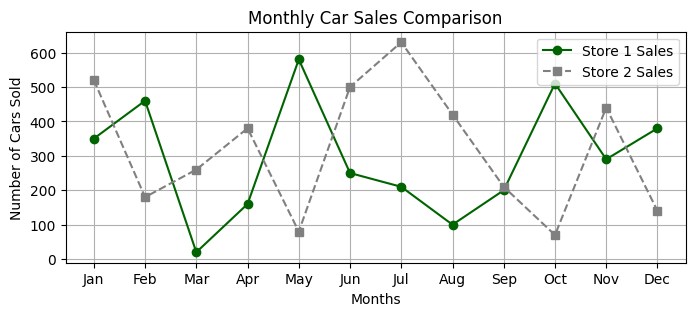

In [162]:
# Plotting Sales Trend
plt.figure(figsize=(8,3))
plt.plot(months, store_1_sales, marker='o', linestyle='-', label='Store 1 Sales', color='darkgreen')
plt.plot(months, store_2_sales, marker='s', linestyle='--', label='Store 2 Sales', color='gray')
plt.xlabel('Months')
plt.ylabel('Number of Cars Sold')
plt.title('Monthly Car Sales Comparison')
plt.legend()
plt.grid(True)
plt.show()

Store 2's sales fluctuate significantly more than Store 1's, showcasing higher volatility.  While both stores experience ups and downs, Store 1 maintains a relatively more consistent sales pattern.  This suggests different market influences or operational factors affecting each store's monthly performance.

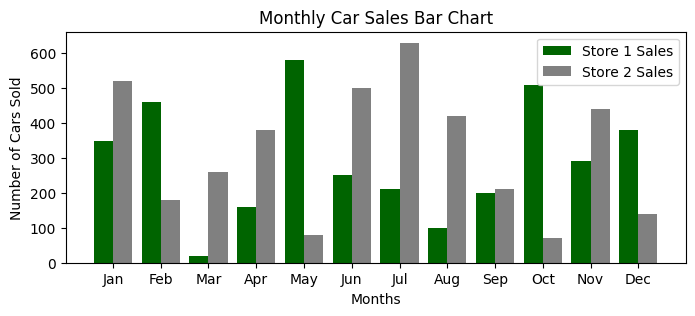

In [160]:
# Bar Plots
plt.figure(figsize=(8,3))
x = np.arange(len(months))
width = 0.4
plt.bar(x - width/2, store_1_sales, width, label='Store 1 Sales', color='darkgreen')
plt.bar(x + width/2, store_2_sales, width, label='Store 2 Sales', color='gray')
plt.xticks(ticks=x, labels=months)
plt.xlabel('Months')
plt.ylabel('Number of Cars Sold')
plt.title('Monthly Car Sales Bar Chart')
plt.legend()
plt.show()

This clustered bar chart compares monthly car sales for two stores, Store 1 (green) and Store 2 (gray), across a year.  It visually represents the number of cars sold each month, allowing for direct comparison of each store's performance.

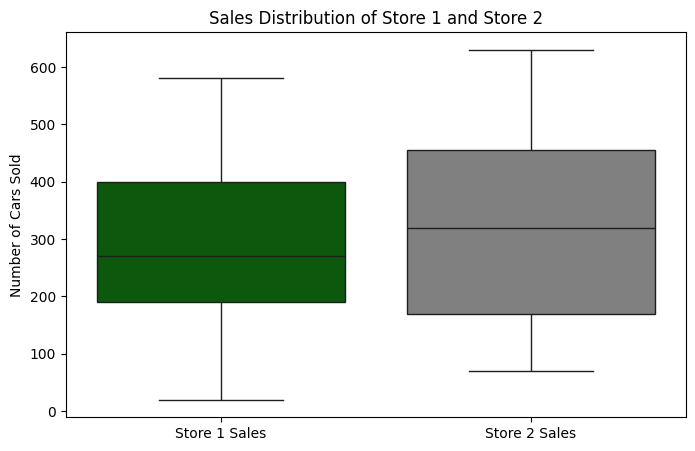

In [161]:
# Seaborn Boxplot for Distribution Analysis
plt.figure(figsize=(8,5))
sns.boxplot(data=data[['Store 1 Sales', 'Store 2 Sales']], palette=['darkgreen', 'gray'])
plt.title('Sales Distribution of Store 1 and Store 2')
plt.ylabel('Number of Cars Sold')
plt.show()

Store 2 has a slightly higher median car sales than Store 1, but both stores show significant variability in sales.  There's considerable overlap in the middle 50% of sales for both stores.

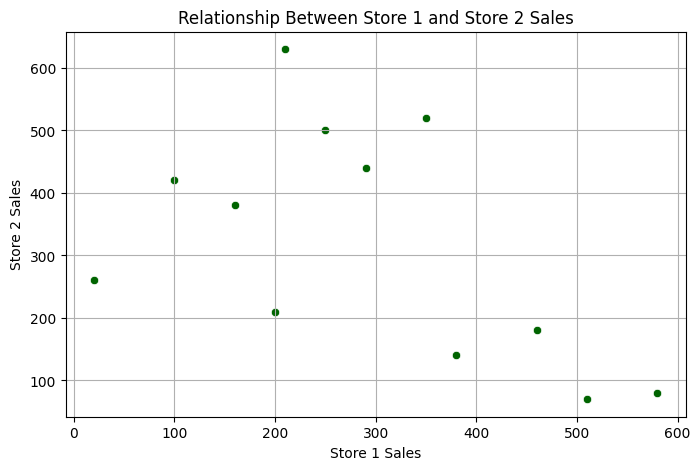

In [16]:
# Scatter Plot to Show Relationship Between Store Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x=store_1_sales, y=store_2_sales, color='darkgreen')
plt.xlabel('Store 1 Sales')
plt.ylabel('Store 2 Sales')
plt.title('Relationship Between Store 1 and Store 2 Sales')
plt.grid(True)
plt.show()

The scatter plot shows no strong linear correlation between Store 1 and Store 2 sales, indicating that sales in one store do not reliably predict sales in the other.

QUESTION 2

In [17]:
# Loading the dataset
house_price = pd.read_csv("house_price.csv")

In [20]:
# Displaying the first 5 rows in a table format
import IPython.display as display
display.display(house_price.head(5))

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


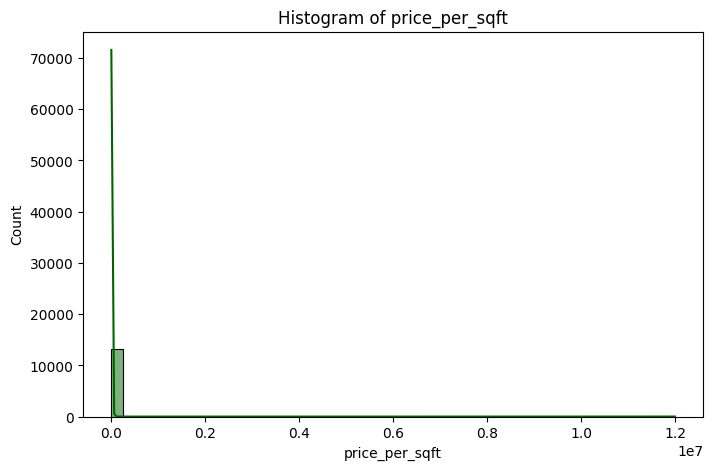

In [156]:
# 1) Histogram to inspect outliers with kde and curve
plt.figure(figsize=(8, 5))
sns.histplot(house_price['price_per_sqft'], bins=50, kde=True, color='darkgreen')
plt.title("Histogram of price_per_sqft")
plt.show()

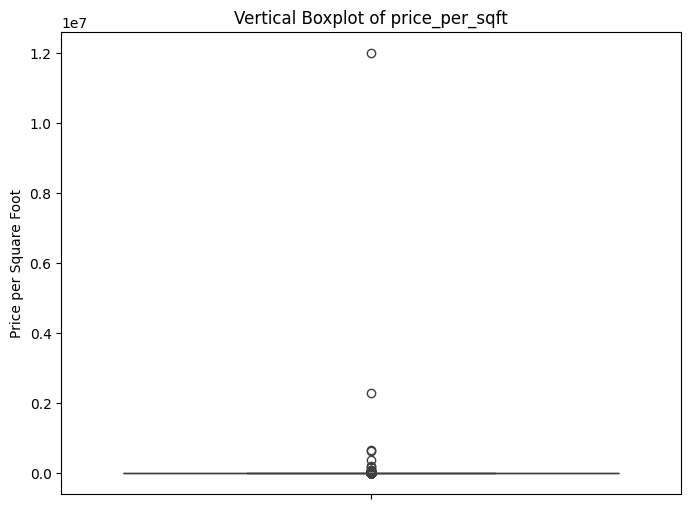

In [49]:
# Plotting a vertical boxplot for price_per_sqft after removing outliers using IQR
plt.figure(figsize=(8, 6))
sns.boxplot(y=house_price['price_per_sqft'])
plt.title('Vertical Boxplot of price_per_sqft')
plt.ylabel('Price per Square Foot')
plt.show()

2

In [29]:
# 2) Showing the range of price_per_sqft that covers the 95% and 99.7% of the area
mean = house_price['price_per_sqft'].mean()
std = house_price['price_per_sqft'].std()

# For 95% (mean +/- 2 std)
lower_95 = mean - 2 * std
upper_95 = mean + 2 * std

# For 99.7% (mean +/- 3 std)
lower_997 = mean - 3 * std
upper_997 = mean + 3 * std

print(f"95% Range: {lower_95} to {upper_95}")
print(f"99.7% Range: {lower_997} to {upper_997}")

95% Range: -205533.98391379268 to 221374.65739864114
99.7% Range: -312261.1442419011 to 328101.8177267496


3

In [121]:
# 3) Removing outliers using IQR technique
Q1 = house_price['price_per_sqft'].quantile(0.25)
Q3 = house_price['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

lower_threshold = Q1 - 1.5 * IQR
upper_threshold = Q3 + 1.5 * IQR

# Removing outliers
house_price_no_outliers_iqr = house_price[(house_price['price_per_sqft'] >= lower_threshold) & (house_price['price_per_sqft'] <= upper_threshold)]

# Displaying the new data frame
display.display(house_price_no_outliers_iqr.head())

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


4

In [126]:
# 4) Size of the new data frame after removing outliers using IQR
display.display(f"Size of the new data frame after IQR removal: {house_price_no_outliers_iqr.shape}")

'Size of the new data frame after IQR removal: (11935, 7)'

5

In [134]:
# Step 5: Remove Outliers using 3 Standard Deviations ###
lower_bound_std = mean - (3 * std)
upper_bound_std = mean + (3 * std)

house_price_no_outliers_std = house_price[
    (house_price['price_per_sqft'] >= lower_bound_std) & (house_price['price_per_sqft'] <= upper_bound_std)
]

display.display("Size after removing outliers using 3 standard deviations:", house_price_no_outliers_std.shape)


'Size after removing outliers using 3 standard deviations:'

(13195, 7)

6

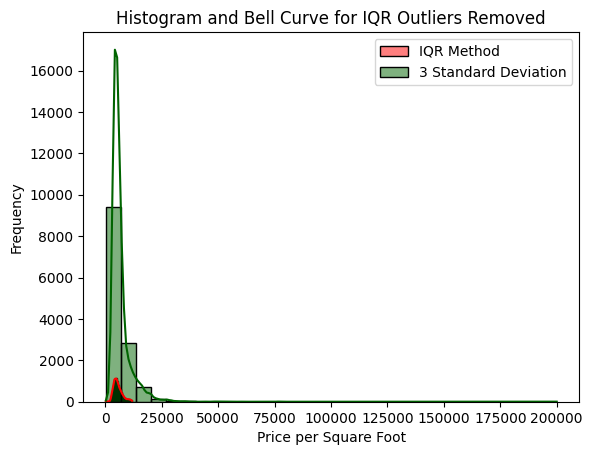

In [141]:
# Plotting histogram and bell curve for IQR method
sns.histplot(house_price_no_outliers_iqr['price_per_sqft'], kde=True, bins=30, color='red', label='IQR Method')
plt.title('Histogram and Bell Curve for IQR Outliers Removed')
plt.xlabel('Price per Square Foot')
plt.ylabel('Frequency')

# Plotting histogram and bell curve for 3 standard deviation method
sns.histplot(house_price_no_outliers_std['price_per_sqft'], kde=True, bins=30, color='darkgreen', label='3 Standard Deviation')
plt.legend()
plt.show()

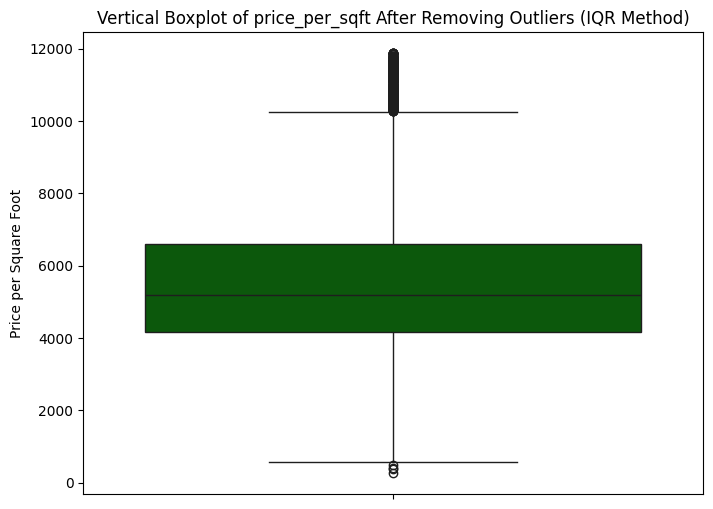

In [81]:
# Plotting a vertical boxplot for price_per_sqft after removing outliers using IQR
plt.figure(figsize=(8, 6))
sns.boxplot(y=house_price_no_outliers_iqr['price_per_sqft'], color='darkgreen')  # Set box color to dark green
plt.title('Vertical Boxplot of price_per_sqft After Removing Outliers (IQR Method)')
plt.ylabel('Price per Square Foot')
plt.show()

8

In [41]:
from scipy import stats
# 8) Removing outliers using Z-Score of 3
z_scores = stats.zscore(house_price['price_per_sqft'])
house_price_no_outliers_zscore = house_price[(z_scores >= -3) & (z_scores <= 3)]

# Display the new data frame after Z-Score removal
display.display(house_price_no_outliers_zscore.head())

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


QUESTION 3

In [148]:
# Loading the dataset
wind_quality = pd.read_csv("/content/winequality-red.csv")

In [149]:
display.display(wind_quality.head(5))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


1

In [150]:
# Checking for missing or duplicate values
display.display("Missing values:", wind_quality.isnull().sum())
display.display("Duplicate values:", wind_quality.duplicated().sum())

'Missing values:'

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


'Duplicate values:'

np.int64(240)

In [54]:
# Removeing missing and duplicate rows
wind_quality = wind_quality.dropna()
wind_quality = wind_quality.drop_duplicates()

2

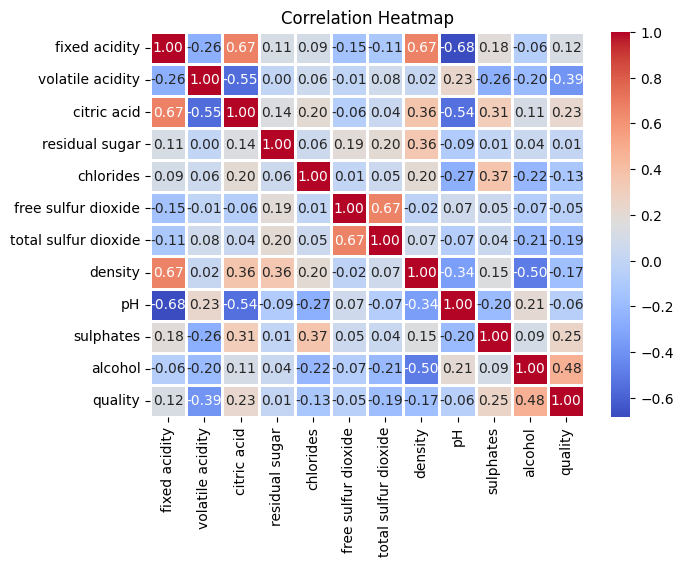

In [152]:
# Correlation and ploting a heatmap
plt.figure(figsize=(7, 5))
correlation_matrix = wind_quality.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Correlation Heatmap')
plt.show()

The heatmap provides an overview of the linear relationships between the variables. It shows key relationships, such as the strong link between fixed acidity and pH, the positive association between alcohol and quality, and the negative impact of volatile acidity on quality.

3

In [153]:
# Find unique quality values and show a bar graph
unique_qualities = wind_quality['quality'].nunique()
display.display(f"Unique quality values: {unique_qualities}")

quality_counts = wind_quality['quality'].value_counts()
display.display("Quality Counts:", quality_counts)

'Unique quality values: 6'

'Quality Counts:'

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


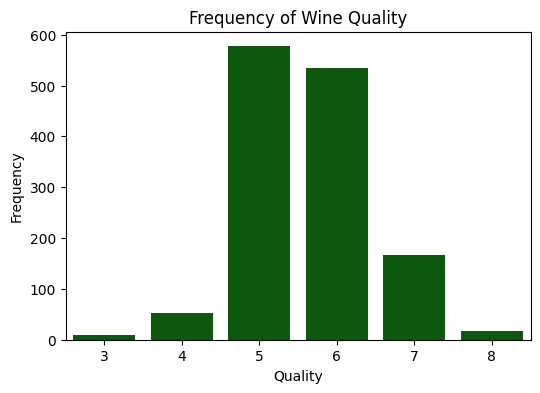

In [75]:
# Bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x=quality_counts.index, y=quality_counts.values, color='darkgreen')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.title('Frequency of Wine Quality')
plt.show()

4

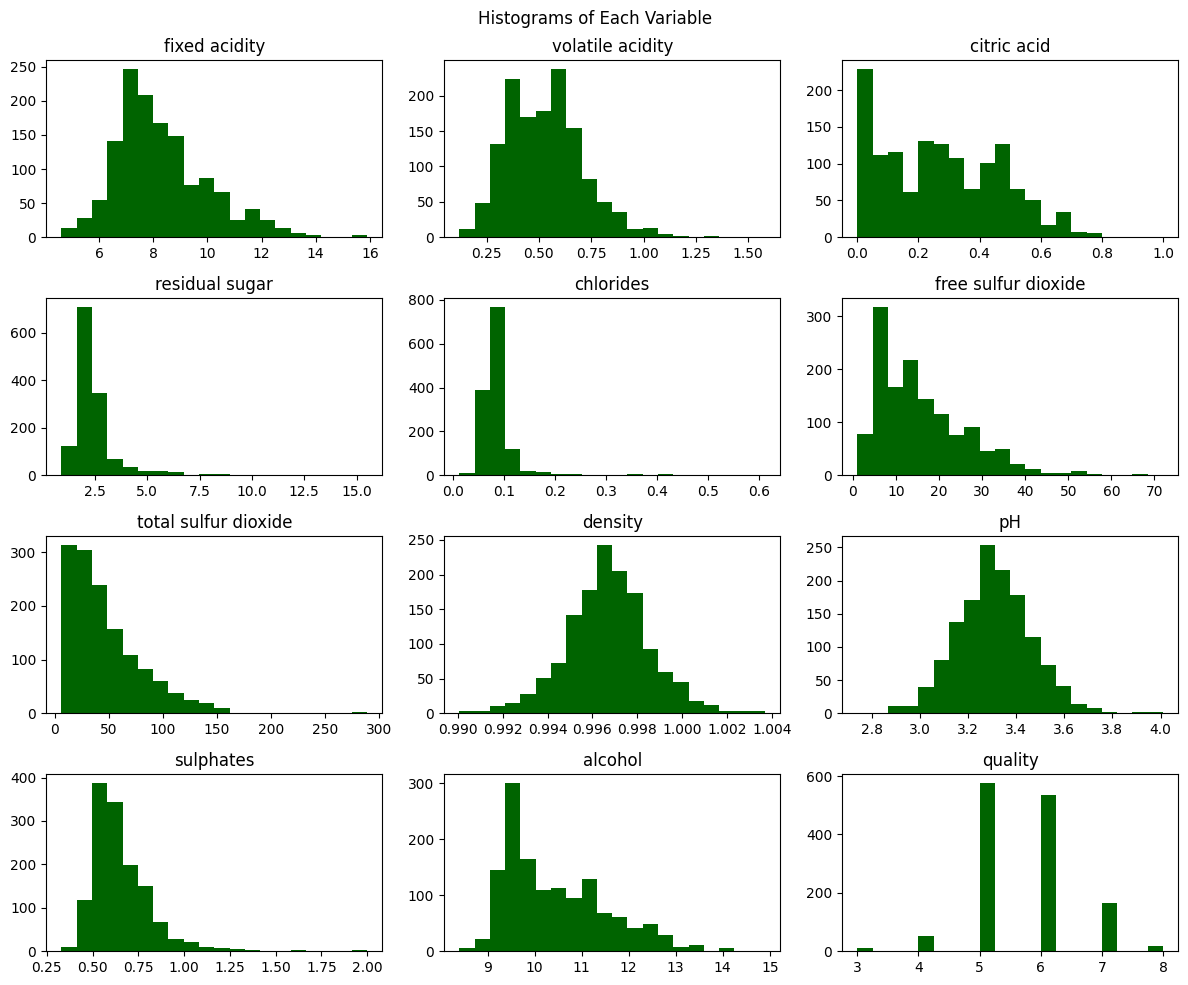

In [74]:
# Plot histograms of each variable and check for outliers
axes = wind_quality.hist(bins=20, figsize=(12, 10), color='darkgreen')  # Set histogram color to dark green
plt.suptitle('Histograms of Each Variable')

# Remove the grid for each axis
for ax in axes.flatten():
    ax.grid(False)

plt.tight_layout()
plt.show()

Most variables have characteristics such as long tails, skewness, in their histograms, indicating values that deviate significantly from the main distribution.

5

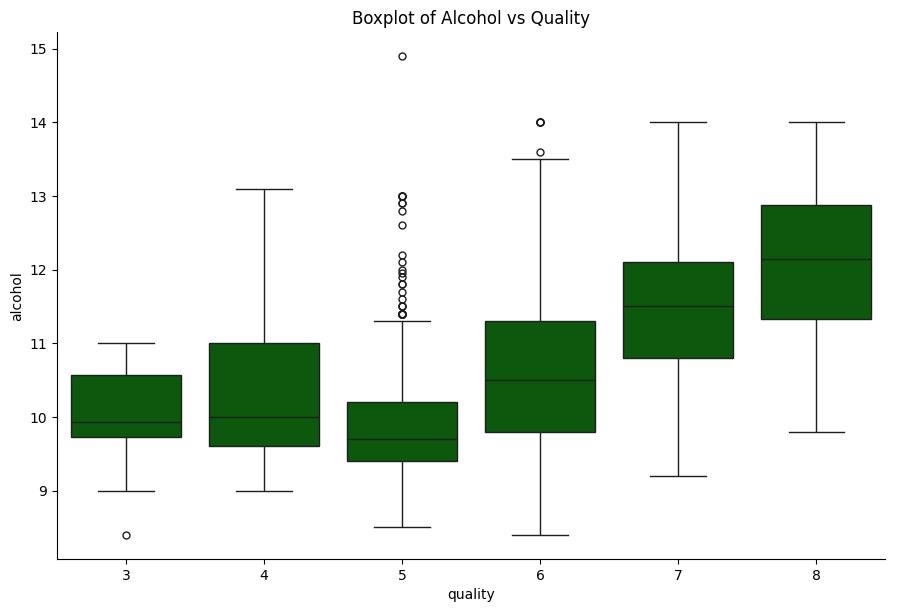

In [154]:
# 5) Side-by-side box plot between Quality and Alcohol
sns.catplot(data=wind_quality, x='quality', y='alcohol', kind='box', height=6, aspect=1.5, color='darkgreen')
plt.title('Boxplot of Alcohol vs Quality')
plt.grid(False)
plt.show()

The boxplot shows higher alcohol content generally corresponds to better wine quality, but there's difference within each quality rating, indicating other factors also influence quality.

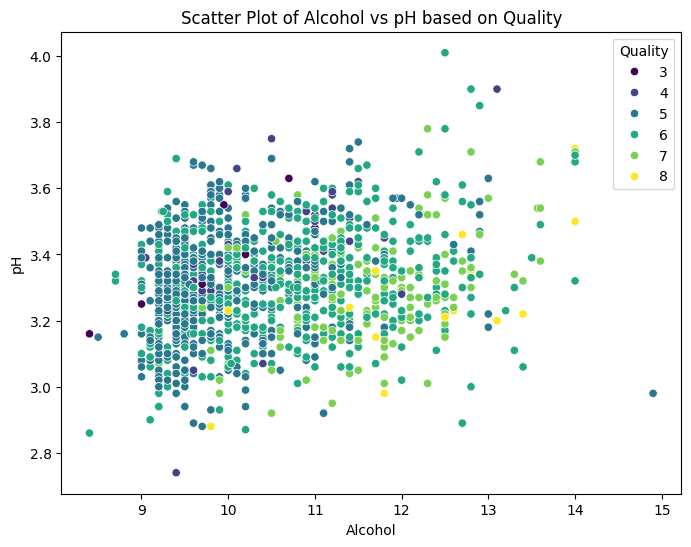

In [155]:
# Scatter plot between "Alcohol" and "pH" based on "Quality"
plt.figure(figsize=(8, 6))
sns.scatterplot(data=wind_quality, x='alcohol', y='pH', hue='quality', palette='viridis')
plt.title('Scatter Plot of Alcohol vs pH based on Quality')
plt.xlabel('Alcohol')
plt.ylabel('pH')
plt.legend(title='Quality')
plt.show()

QUESTION 4

1

In [116]:
# Loading the dataset
iris = pd.read_csv('/content/iris.csv')
display.display(iris.head(5))

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [117]:
iris['petal_ratio'] = iris['petal_length'] / iris['petal_width']
iris['sepal_ratio'] = iris['sepal_length'] / iris['sepal_width']
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species,petal_ratio,sepal_ratio
0,5.1,3.5,1.4,0.2,setosa,7.0,1.457143
1,4.9,3.0,1.4,0.2,setosa,7.0,1.633333
2,4.7,3.2,1.3,0.2,setosa,6.5,1.468750
3,4.6,3.1,1.5,0.2,setosa,7.5,1.483871
4,5.0,3.6,1.4,0.2,setosa,7.0,1.388889


Ratio for descriptive statistics and aggregates output.


In [122]:
# Group by species and calculate summary statistics
aggregates = iris.groupby('species')[['petal_ratio', 'sepal_ratio']].agg(['mean', 'median', 'min', 'max', 'std'])

# Displaying the result
aggregates

petal_ratio                                     sepal_ratio  \
                  mean    median       min   max       std        mean   
species                                                                  
setosa        7.078000  7.000000  2.666667  15.0  3.123779    1.474578   
versicolor    3.242837  3.240385  2.666667   4.1  0.312456    2.160402   
virginica     2.780662  2.666667  2.125000   4.0  0.407367    2.230453   

                                                    
              median       min       max       std  
species                                             
setosa      1.467708  1.268293  1.956522  0.118693  
versicolor  2.161290  1.764706  2.818182  0.228658  
virginica   2.169540  1.823529  2.961538  0.246992

2

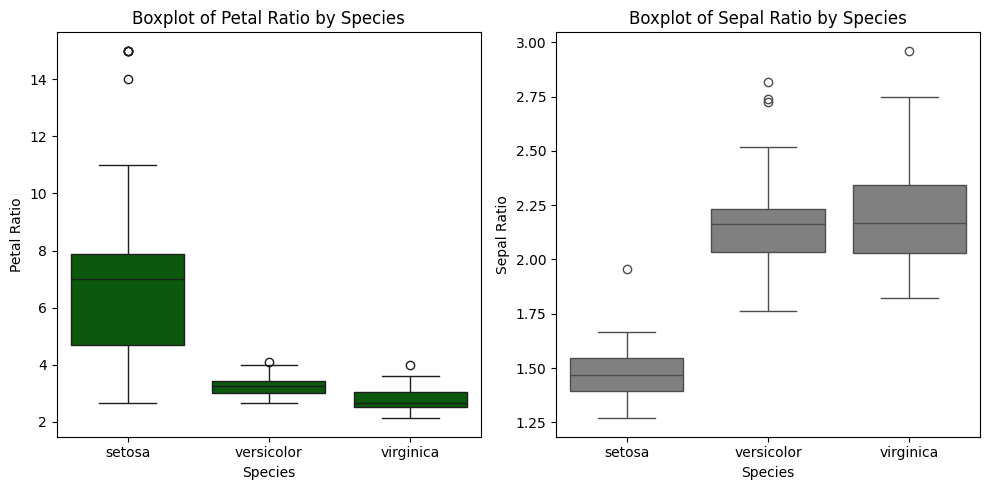

In [124]:
# Setting figure size
plt.figure(figsize=(10,5))

# Boxplot for petal ratio
plt.subplot(1,2,1)
sns.boxplot(x='species', y='petal_ratio', data=iris, color='darkgreen')
plt.xlabel('Species')
plt.ylabel('Petal Ratio')
plt.title('Boxplot of Petal Ratio by Species')

# Boxplot for sepal ratio
plt.subplot(1,2,2)
sns.boxplot(x='species', y='sepal_ratio', data=iris, color='gray')
plt.xlabel('Species')
plt.ylabel('Sepal Ratio')
plt.title('Boxplot of Sepal Ratio by Species')
plt.tight_layout()
plt.show()

The two boxplots comparing the petal ratio and sepal ratio across three species of Iris flowers. It highlights the differences in the distribution of these ratios among the species.

3

'Correlation between Petal Ratio and Sepal Ratio:\n'

,petal_ratio,sepal_ratio
petal_ratio,1.000000,-0.583908
sepal_ratio,-0.583908,1.000000


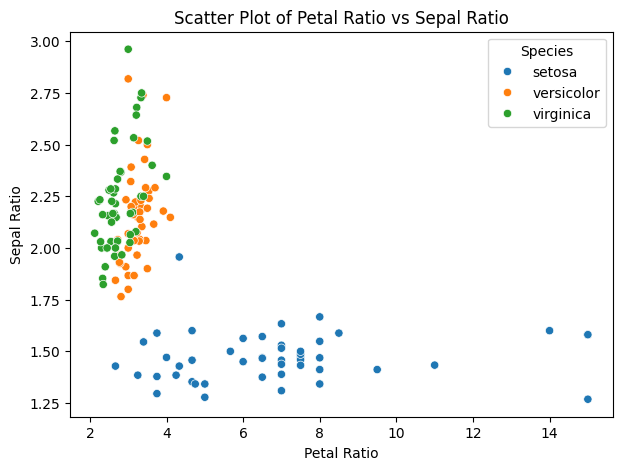

In [146]:
# Calculating correlation
correlation = iris[['petal_ratio', 'sepal_ratio']].corr()
display.display("Correlation between Petal Ratio and Sepal Ratio:\n", correlation)

# Scatter plot
plt.figure(figsize=(7,5))
sns.scatterplot(x=iris['petal_ratio'], y=iris['sepal_ratio'], hue=iris['species'])
plt.xlabel('Petal Ratio')
plt.ylabel('Sepal Ratio')
plt.title('Scatter Plot of Petal Ratio vs Sepal Ratio')
plt.legend(title='Species')
plt.show()

There is a moderate negative correlation between "Petal Ratio" and "Sepal Ratio". This means that as the petal ratio increases, the sepal ratio tends to decrease. The scatter plot shows a general downward trend with some scatter. The species information reveals that the correlation is influenced by the some characteristics of each species.

4

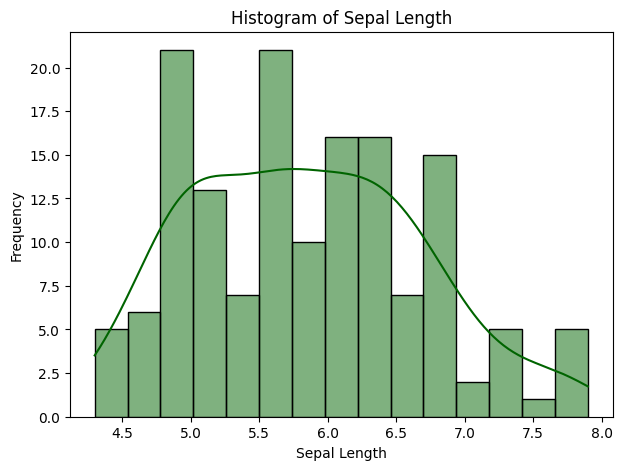

In [143]:
# Histogram for sepal length
plt.figure(figsize=(7,5))
sns.histplot(iris['sepal_length'], bins=15, kde=True, color='darkgreen')
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.title('Histogram of Sepal Length')
plt.show()

The histogram provides a clear overview of the distribution of sepal length in the dataset, highlighting its normality, range, mode, and absence of outliers.

5

In [107]:
# Mean and standard deviation
mean_sepal_length = iris['sepal_length'].mean()
std_sepal_length = iris['sepal_length'].std()

# Ranges for 68% and 95%
low_68, high_68 = mean_sepal_length - std_sepal_length, mean_sepal_length + std_sepal_length
low_95, high_95 = mean_sepal_length - (2*std_sepal_length), mean_sepal_length + (2*std_sepal_length)

# Displaying results
display.display(f"68% of Sepal Length Data is between {low_68:.2f} and {high_68:.2f}")
display.display(f"95% of Sepal Length Data is between {low_95:.2f} and {high_95:.2f}")

'68% of Sepal Length Data is between 5.02 and 6.67'

'95% of Sepal Length Data is between 4.19 and 7.50'

6

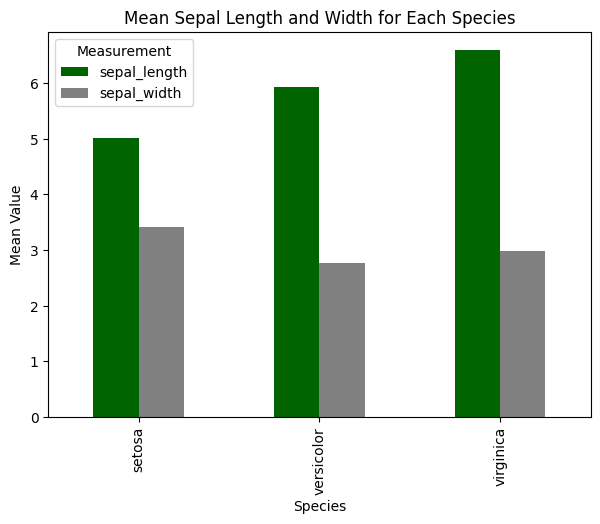

In [144]:
# Calculating mean and std
sepal_stats = iris.groupby('species')[['sepal_length', 'sepal_width']].agg(['mean', 'std'])
sepal_means = iris.groupby('species')[['sepal_length', 'sepal_width']].mean()

# Plot
ax = sepal_means.plot(kind='bar', figsize=(7,5), color=['darkgreen', 'grey'])

# Adding titles and labels
plt.xlabel('Species')
plt.ylabel('Mean Value')
plt.title('Mean Sepal Length and Width for Each Species')
plt.legend(title='Measurement')
plt.show()